In [1]:
# First cell of 03_modelling.ipynb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# Load final panel
panel = pd.read_csv(
    "dissertation_data/processed/panel_final.csv"
)

print("=" * 55)
print("03 — MODELLING")
print("=" * 55)
print(f"Panel loaded: {panel.shape}")
print(f"Countries: {panel['country'].unique()}")
print(f"Years: {panel['year'].min()} to {panel['year'].max()}")
print(f"Target: gdp_growth")
print(f"Features: {len(panel.columns) - 3} variables")
print()
print("Models to build:")
print("  Model 1 → VAR (Vector Autoregression)")
print("  Model 2 → Random Forest")
print("  Model 3 → XGBoost")
print()
print("Ready to start!")

03 — MODELLING
Panel loaded: (210, 42)
Countries: <StringArray>
['Bangladesh', 'India', 'Japan', 'Pakistan', 'Singapore', 'South Korea']
Length: 6, dtype: str
Years: 1990 to 2024
Target: gdp_growth
Features: 39 variables

Models to build:
  Model 1 → VAR (Vector Autoregression)
  Model 2 → Random Forest
  Model 3 → XGBoost

Ready to start!


In [2]:
####splitting the training and testing data
import warnings
warnings.filterwarnings('ignore')

print("=" * 55)
print("TRAIN / VALIDATION / TEST SPLIT")
print("=" * 55)

# ── Temporal Split ─────────────────────────────────────
train = panel[panel['year'] <= 2019].copy()
val   = panel[(panel['year'] >= 2020) &
              (panel['year'] <= 2021)].copy()
test  = panel[panel['year'] >= 2022].copy()

print(f"\nTRAIN:      1990-2019 → {len(train)} rows")
print(f"VALIDATION: 2020-2021 → {len(val)} rows")
print(f"TEST:       2022-2024 → {len(test)} rows")


TRAIN / VALIDATION / TEST SPLIT

TRAIN:      1990-2019 → 180 rows
VALIDATION: 2020-2021 → 12 rows
TEST:       2022-2024 → 18 rows


In [3]:
panel.head(5)

,country,year,gdp_growth,inflation,unemployment,remittance_pct_gdp,exchange_rate_usd,energy_imports_pct,brent_crude_usd,lng_price_usd,...,oil_shock_signal_lag1,gpr_normalised_lag1,brent_crude_usd_lag1,inflation_lag1,hormuz_disruption_lag1,baltic_dry_index_lag1,trade_exposure_score,country_encoded,crop_production_index,food_production_index
0,Bangladesh,1990,5.622258,6.126718,2.200,2.464894,34.568808,16.925278,23.76,3.56,...,NaN,NaN,NaN,NaN,NaN,NaN,19.3902,0,45.08,42.68
1,Bangladesh,1991,3.485228,6.357364,2.200,2.485233,36.596183,14.567510,20.04,3.01,...,0.0000,0.6312,23.76,6.126718,0.0000,1347.50,17.0527,0,47.08,43.47
2,Bangladesh,1992,5.442686,3.634077,2.233,2.875409,38.950758,14.098282,19.32,2.90,...,-0.7071,1.5623,20.04,6.357364,-0.9887,1595.42,16.9737,0,47.47,43.97
3,Bangladesh,1993,4.711562,3.014819,2.310,3.037325,39.567257,13.953878,17.01,2.55,...,-0.7218,-0.5977,19.32,3.634077,-0.8904,1198.67,16.9912,0,47.00,43.92
4,Bangladesh,1994,3.890126,5.313740,2.370,3.408134,40.211739,15.285043,15.86,2.38,...,-1.0791,-0.0145,17.01,3.014819,-1.6010,1398.08,18.6932,0,44.94,42.58


In [4]:
##Defining the features and target
# Target
target = 'gdp_growth'
# Features for ML models (Random Forest + XGBoost)
# Exclude identifiers and target
exclude_cols = [
    'country', 'year', 'gdp_growth',
    'country_encoded'
]

ml_features = [
    col for col in panel.columns
    if col not in exclude_cols
]
print(f"\nTarget variable: {target}")
print(f"ML Features ({len(ml_features)}):")
for i, f in enumerate(ml_features):
    print(f"  {i+1:2d}. {f}")




Target variable: gdp_growth
ML Features (38):
   1. inflation
   2. unemployment
   3. remittance_pct_gdp
   4. exchange_rate_usd
   5. energy_imports_pct
   6. brent_crude_usd
   7. lng_price_usd
   8. baltic_dry_index
   9. gpr_global
  10. gpr_threat
  11. gpr_act
  12. gpr_india
  13. gpr_japan
  14. gpr_korea
  15. food_price_index
  16. cereals_index
  17. oils_index
  18. fertilizer_price_index
  19. fertilizer_consumption
  20. hormuz_flow_mbd
  21. reserve_days
  22. oil_rents_pct_gdp
  23. debt_gdp
  24. oil_shock_signal
  25. hormuz_disruption
  26. oil_x_buffer
  27. gpr_normalised
  28. fertilizer_shock
  29. conflict_dummy
  30. oil_shock_signal_lag1
  31. gpr_normalised_lag1
  32. brent_crude_usd_lag1
  33. inflation_lag1
  34. hormuz_disruption_lag1
  35. baltic_dry_index_lag1
  36. trade_exposure_score
  37. crop_production_index
  38. food_production_index


In [5]:

# VAR features — smaller focused set

### what is this feature and why?
var_features = [
    'gdp_growth',
    'brent_crude_usd',
    'inflation',
    'gpr_global',
    'hormuz_flow_mbd',
    'baltic_dry_index'
]
print(f"\nVAR Features ({len(var_features)}):")
for f in var_features:
    print(f"  {f}")


VAR Features (6):
  gdp_growth
  brent_crude_usd
  inflation
  gpr_global
  hormuz_flow_mbd
  baltic_dry_index


In [6]:
# ── Prepare ML arrays ─────────────────────────────────
print("\n" + "=" * 55)
print("PREPARING ML ARRAYS")
print("=" * 55)

# Drop rows with missing target
train_clean = train.dropna(subset=[target])
val_clean   = val.dropna(subset=[target])
test_clean  = test.dropna(subset=[target])

# Drop rows with missing features
train_clean = train_clean.dropna(subset=ml_features)
val_clean   = val_clean.dropna(subset=ml_features)
test_clean  = test_clean.dropna(subset=ml_features)

# X and y arrays
X_train = train_clean[ml_features].values
y_train = train_clean[target].values

X_val   = val_clean[ml_features].values
y_val   = val_clean[target].values

X_test  = test_clean[ml_features].values
y_test  = test_clean[target].values

print(f"\nX_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}")


PREPARING ML ARRAYS

X_train: (174, 38)
y_train: (174,)
X_val:   (12, 38)
y_val:   (12,)
X_test:  (18, 38)
y_test:  (18,)


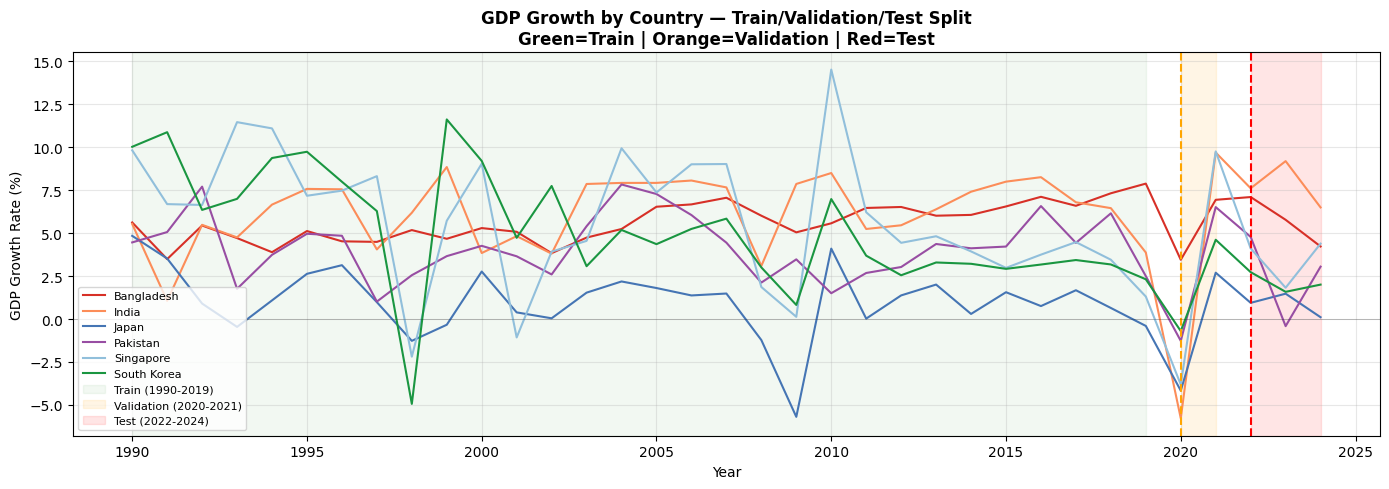


SPLIT COMPLETE — READY FOR MODELLING!

Next steps:
  Model 1 → VAR
  Model 2 → Random Forest
  Model 3 → XGBoost


In [7]:
# ── Visualise the split ───────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

colors_split = {
    'Bangladesh': '#d73027',
    'India':      '#fc8d59',
    'Japan':      '#4575b4',
    'Pakistan':   '#984ea3',
    'Singapore':  '#91bfdb',
    'South Korea':'#1a9641'
}

for country in panel['country'].unique():
    df_c = panel[
        panel['country'] == country
    ].dropna(subset=['gdp_growth'])

    ax.plot(
        df_c['year'],
        df_c['gdp_growth'],
        color=colors_split[country],
        linewidth=1.5,
        label=country
    )

# Shade splits
ax.axvspan(1990, 2019, alpha=0.05,
           color='green', label='Train (1990-2019)')
ax.axvspan(2020, 2021, alpha=0.1,
           color='orange', label='Validation (2020-2021)')
ax.axvspan(2022, 2024, alpha=0.1,
           color='red', label='Test (2022-2024)')

ax.axvline(x=2020, color='orange',
           linestyle='--', linewidth=1.5)
ax.axvline(x=2022, color='red',
           linestyle='--', linewidth=1.5)
ax.axhline(y=0, color='black',
           linestyle='-', linewidth=0.5, alpha=0.3)
ax.set_title(
    'GDP Growth by Country — Train/Validation/Test Split\n'
    'Green=Train | Orange=Validation | Red=Test',
    fontweight='bold', fontsize=12
)
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('GDP Growth Rate (%)', fontsize=10)
ax.legend(fontsize=8, loc='lower left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    'dissertation_data/processed/figures/train_test_split.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

print("\n" + "=" * 55)
print("SPLIT COMPLETE — READY FOR MODELLING!")
print("=" * 55)
print("\nNext steps:")
print("  Model 1 → VAR")
print("  Model 2 → Random Forest")
print("  Model 3 → XGBoost")


In [8]:
###step 2---EDA
train = panel[panel['year'] <= 2019].copy()

# ── 1. Descriptive Statistics ─────────────────────────
print("\n1. DESCRIPTIVE STATISTICS — TRAINING SET")
print("-" * 45)

key_vars = [
    'gdp_growth', 'brent_crude_usd',
    'inflation', 'gpr_global',
    'hormuz_flow_mbd', 'baltic_dry_index',
    'reserve_days', 'remittance_pct_gdp',
    'debt_gdp', 'fertilizer_price_index'
]
desc = train[key_vars].describe().round(2)
print(desc)




1. DESCRIPTIVE STATISTICS — TRAINING SET
---------------------------------------------
       gdp_growth  brent_crude_usd  inflation  gpr_global  hormuz_flow_mbd  \
count      180.00           180.00     180.00      180.00           180.00   
mean         4.71            49.17       4.59      100.04            16.50   
std          3.05            31.96       3.91       29.70             2.13   
min         -5.69            12.76      -1.35       50.91            13.95   
25%          2.96            20.04       1.38       83.04            14.52   
50%          4.73            40.95       3.79       96.15            16.27   
75%          6.66            71.33       7.08      105.95            18.05   
max         14.52           111.57      20.29      176.30            21.40   

       baltic_dry_index  reserve_days  remittance_pct_gdp  debt_gdp  \
count            180.00        180.00              180.00    180.00   
mean            1997.43         51.63                2.16     73.48

In [ ]:
###what should we check on the describe, mean? median? and for what?
#count to check sabai ma same xa number or kunai missing xa vanera.
#higher the std=> higher the outliers
# if q1 =q3-> most values are the same (low variance)
##basically to see the distribution and finding the outliers.

In [9]:
# ── 2. GDP Growth by Country ──────────────────────────
print("\n2. GDP GROWTH SUMMARY BY COUNTRY (TRAIN)")
print("-" * 45)
gdp_summary = (train
    .groupby('country')['gdp_growth']
    .agg(['mean', 'std', 'min', 'max'])
    .round(2)
)
print(gdp_summary)


2. GDP GROWTH SUMMARY BY COUNTRY (TRAIN)
---------------------------------------------
             mean   std   min    max
country                             
Bangladesh   5.62  1.10  3.49   7.88
India        6.23  1.92  1.06   8.85
Japan        1.06  1.94 -5.69   4.84
Pakistan     4.21  1.78  1.01   7.83
Singapore    5.86  3.83 -2.19  14.52
South Korea  5.27  3.46 -4.94  11.62


In [10]:

# ── 3. Correlation with GDP ───────────────────────────
print("\n3. CORRELATION WITH GDP GROWTH (TRAIN)")
print("-" * 45)
correlations = (train[key_vars]
    .corr()['gdp_growth']
    .drop('gdp_growth')
    .sort_values(ascending=False)
    .round(3)
)
print(correlations)



3. CORRELATION WITH GDP GROWTH (TRAIN)
---------------------------------------------
inflation                 0.234
remittance_pct_gdp        0.199
baltic_dry_index          0.068
gpr_global                0.008
hormuz_flow_mbd          -0.066
brent_crude_usd          -0.084
fertilizer_price_index   -0.123
debt_gdp                 -0.458
reserve_days             -0.494
Name: gdp_growth, dtype: float64


In [ ]:
## what should be the correlation value?
# for the train data
# inflaion,remittance has +ve correlation with the gdp
#reserve_days, debt_gdp and fertilizer_price_index has strong but -ve correlation with the gdp

MULTICOLLINEARITY ANALYSIS

Correlation matrix between independent variables:
                        brent_crude_usd  lng_price_usd  inflation  gpr_global  \
brent_crude_usd                    1.00           0.37       0.07       -0.19   
lng_price_usd                      0.37           1.00       0.04        0.14   
inflation                          0.07           0.04       1.00       -0.12   
gpr_global                        -0.19           0.14      -0.12        1.00   
hormuz_flow_mbd                    0.69           0.39      -0.04       -0.12   
baltic_dry_index                   0.25           0.82       0.11        0.03   
reserve_days                       0.10           0.03      -0.62       -0.01   
remittance_pct_gdp                 0.26           0.08       0.55       -0.02   
debt_gdp                           0.19           0.04      -0.45        0.01   
fertilizer_price_index             0.79           0.13      -0.10       -0.18   
oil_shock_signal               

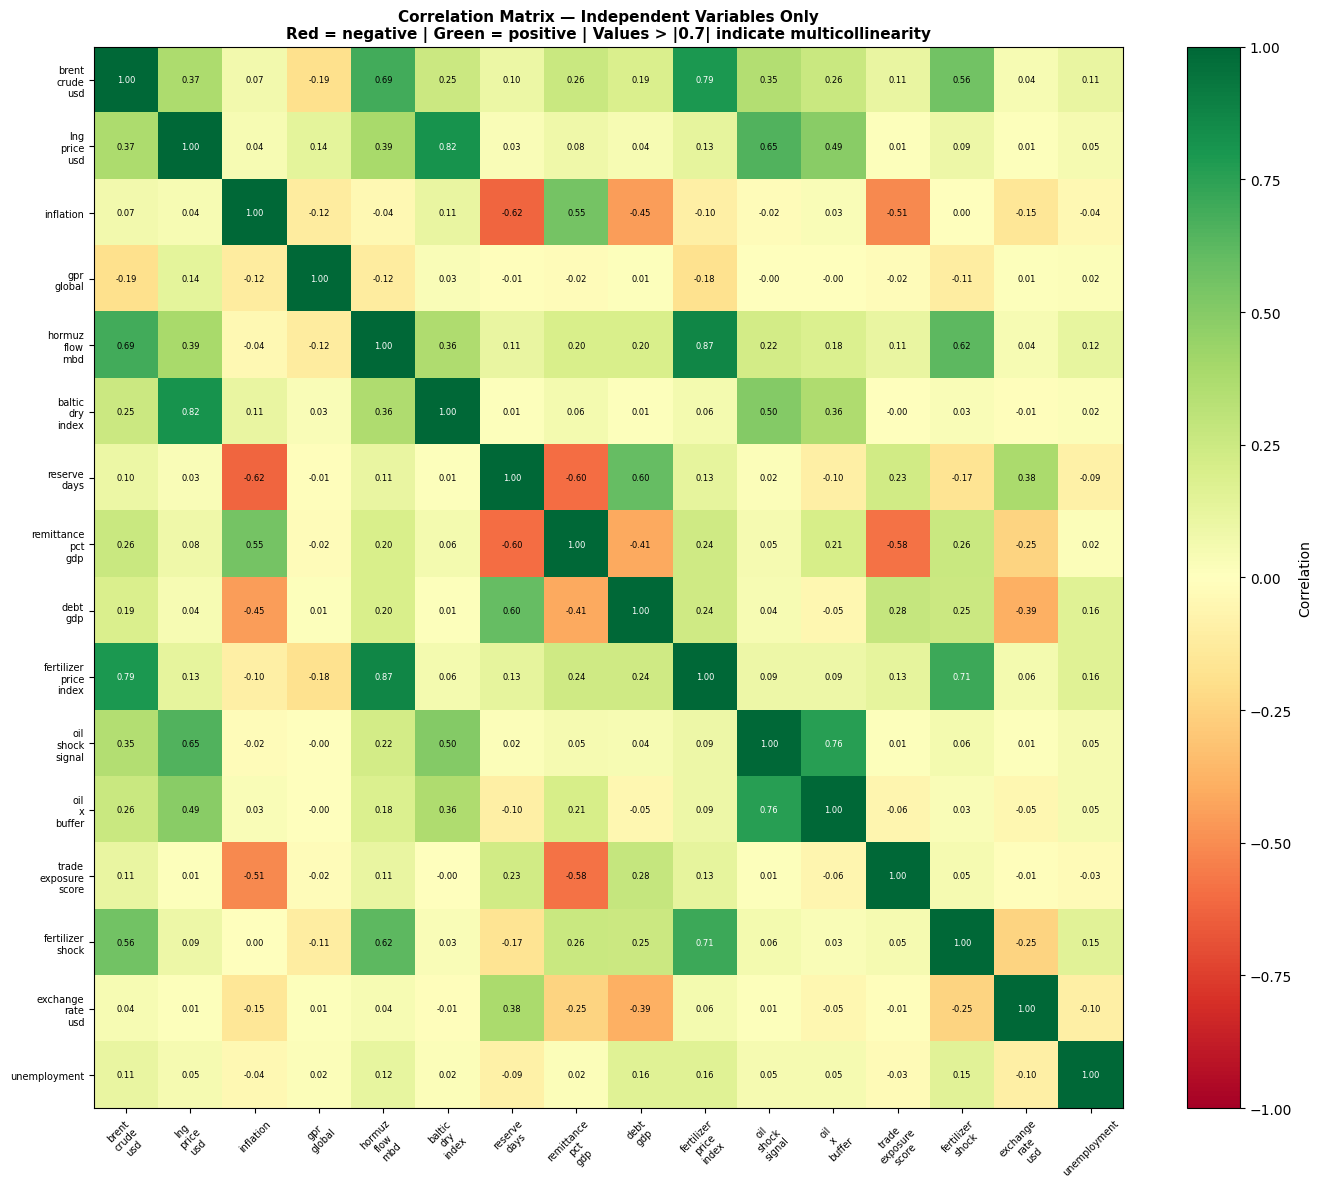

Plot saved!


In [13]:

print("=" * 55)
print("MULTICOLLINEARITY ANALYSIS")
print("=" * 55)

# Independent variables only — exclude target
key_vars = [
    'brent_crude_usd',
    'lng_price_usd',
    'inflation',
    'gpr_global',
    'hormuz_flow_mbd',
    'baltic_dry_index',
    'reserve_days',
    'remittance_pct_gdp',
    'debt_gdp',
    'fertilizer_price_index',
    'oil_shock_signal',
    'oil_x_buffer',
    'trade_exposure_score',
    'fertilizer_shock',
    'exchange_rate_usd',
    'unemployment',
]

df_indep = train[key_vars].dropna()

# Correlation matrix between independent variables
corr_matrix = df_indep.corr().round(2)

print("\nCorrelation matrix between independent variables:")
print(corr_matrix)

# Flag high correlations
print("\n=== HIGH CORRELATIONS (|r| > 0.7) ===")
print("These indicate potential multicollinearity\n")

high_corr_pairs = []
for i in range(len(key_vars)):
    for j in range(i+1, len(key_vars)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr_pairs.append({
                'var1': key_vars[i],
                'var2': key_vars[j],
                'r':    round(r, 3)
            })
            print(f"  {key_vars[i]:30s} vs "
                  f"{key_vars[j]:30s} r={r:.3f}")

if not high_corr_pairs:
    print("  No high correlations found!")

# Visualise
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

im = ax.imshow(
    corr_matrix,
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    aspect='auto'
)

ax.set_xticks(range(len(key_vars)))
ax.set_yticks(range(len(key_vars)))
short = [v.replace('_', '\n') for v in key_vars]
ax.set_xticklabels(short, fontsize=7, rotation=45)
ax.set_yticklabels(short, fontsize=7)
plt.colorbar(im, ax=ax, label='Correlation')

# Add values
for i in range(len(key_vars)):
    for j in range(len(key_vars)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.7 else 'black'
        ax.text(
            j, i, f'{val:.2f}',
            ha='center', va='center',
            fontsize=6, color=color
        )

ax.set_title(
    'Correlation Matrix — Independent Variables Only\n'
    'Red = negative | Green = positive | '
    'Values > |0.7| indicate multicollinearity',
    fontweight='bold', fontsize=11
)
plt.tight_layout()
plt.savefig(
    'dissertation_data/processed/figures/'
    'multicollinearity_matrix.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Plot saved!")

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_vif = train[key_vars].dropna()

print("\n" + "=" * 55)
print("VARIANCE INFLATION FACTOR (VIF)")
print("=" * 55)
print("VIF > 10 = serious multicollinearity")
print("VIF 5-10 = moderate multicollinearity")
print("VIF < 5  = acceptable\n")

vif_data = []
X = df_vif.values

for i, var in enumerate(key_vars):
    try:
        vif = variance_inflation_factor(X, i)
        status = "✓ OK" if vif < 5 \
                 else "⚠ moderate" if vif < 10 \
                 else "✗ HIGH"
        vif_data.append({
            'variable': var,
            'VIF':      round(vif, 2),
            'status':   status
        })
        print(f"  {var:35s} VIF={vif:8.2f}  {status}")
    except Exception as e:
        print(f"  {var:35s} ERROR: {e}")

df_vif_results = pd.DataFrame(vif_data)
df_vif_results.to_csv(
    'dissertation_data/processed/vif_results.csv',
    index=False
)
print("\nVIF results saved!")


VARIANCE INFLATION FACTOR (VIF)
VIF > 10 = serious multicollinearity
VIF 5-10 = moderate multicollinearity
VIF < 5  = acceptable

  brent_crude_usd                     VIF=   17.92  ✗ HIGH
  lng_price_usd                       VIF=   27.50  ✗ HIGH
  inflation                           VIF=    7.51  ⚠ moderate
  gpr_global                          VIF=   14.18  ✗ HIGH
  hormuz_flow_mbd                     VIF=  358.10  ✗ HIGH
  baltic_dry_index                    VIF=    9.53  ⚠ moderate
  reserve_days                        VIF=   23.55  ✗ HIGH
  remittance_pct_gdp                  VIF=    7.88  ⚠ moderate
  debt_gdp                            VIF=   30.80  ✗ HIGH
  fertilizer_price_index              VIF=  346.49  ✗ HIGH
  oil_shock_signal                    VIF=    3.84  ✓ OK
  oil_x_buffer                        VIF=    2.72  ✓ OK
  trade_exposure_score                VIF=    6.12  ⚠ moderate
  fertilizer_shock                    VIF=    3.42  ✓ OK
  exchange_rate_usd              

In [15]:

# Variables to DROP — replaced by engineered features
# or too highly correlated with others
drop_vars = [
    'hormuz_flow_mbd',      # VIF 358 — captured by oil_shock_signal
    'fertilizer_price_index', # VIF 346 — captured by fertilizer_shock
    'lng_price_usd',        # VIF 27.5 — highly correlated with brent
    'gpr_global',           # VIF 14.2 — captured by gpr_normalised
    'gpr_threat',           # correlated with gpr_global
    'gpr_act',              # correlated with gpr_global
    'brent_crude_usd',      # VIF 17.9 — captured by oil_shock_signal
]

# Variables to KEEP — good VIF or unique information
keep_reason = {
    'oil_shock_signal':     'VIF 3.8  — engineered brent signal',
    'oil_x_buffer':         'VIF 2.7  — unique interaction term',
    'fertilizer_shock':     'VIF 3.4  — engineered fertilizer signal',
    'gpr_normalised':       'replaces gpr_global cleanly',
    'inflation':            'VIF 7.5  — unique macro signal',
    'remittance_pct_gdp':   'VIF 7.9  — unique social channel',
    'baltic_dry_index':     'VIF 9.5  — unique trade channel',
    'exchange_rate_usd':    'VIF 8.5  — unique financial channel',
    'reserve_days':         'VIF 23.5 — keep, unique moderator',
    'debt_gdp':             'VIF 30.8 — keep, fiscal channel',
    'unemployment':         'VIF 5.9  — unique labour channel',
    'trade_exposure_score': 'VIF 6.1  — unique composite',
    'food_price_index':     'unique food security channel',
    'crop_production_index':'unique agricultural channel',
}

print("Variables to DROP from ML features:")
for v in drop_vars:
    print(f"  ✗ {v}")

print("\nVariables to KEEP:")
for v, reason in keep_reason.items():
    print(f"  ✓ {v:30s} {reason}")

Variables to DROP from ML features:
  ✗ hormuz_flow_mbd
  ✗ fertilizer_price_index
  ✗ lng_price_usd
  ✗ gpr_global
  ✗ gpr_threat
  ✗ gpr_act
  ✗ brent_crude_usd

Variables to KEEP:
  ✓ oil_shock_signal               VIF 3.8  — engineered brent signal
  ✓ oil_x_buffer                   VIF 2.7  — unique interaction term
  ✓ fertilizer_shock               VIF 3.4  — engineered fertilizer signal
  ✓ gpr_normalised                 replaces gpr_global cleanly
  ✓ inflation                      VIF 7.5  — unique macro signal
  ✓ remittance_pct_gdp             VIF 7.9  — unique social channel
  ✓ baltic_dry_index               VIF 9.5  — unique trade channel
  ✓ exchange_rate_usd              VIF 8.5  — unique financial channel
  ✓ reserve_days                   VIF 23.5 — keep, unique moderator
  ✓ debt_gdp                       VIF 30.8 — keep, fiscal channel
  ✓ unemployment                   VIF 5.9  — unique labour channel
  ✓ trade_exposure_score           VIF 6.1  — unique composite


In [17]:


train = panel[panel['year'] <= 2019].copy()

print("=" * 55)
print("FINAL FEATURE SELECTION")
print("=" * 55)

# Final clean feature list
# Keeping engineered versions, dropping raw correlated ones
ml_features_clean = [
    # Energy shock — engineered (replaces raw brent + hormuz)
    'oil_shock_signal',
    'oil_x_buffer',
    'hormuz_disruption',      # replaces hormuz_flow_mbd

    # Geopolitical — engineered (replaces raw gpr)
    'gpr_normalised',
    'conflict_dummy',

    # Trade and freight
    'baltic_dry_index',
    'trade_exposure_score',

    # Macro controls
    'inflation',
    'exchange_rate_usd',
    'unemployment',
    'debt_gdp',

    # Social channel
    'remittance_pct_gdp',

    # Food and fertilizer — engineered
    'fertilizer_shock',
    'food_price_index',
    'crop_production_index',

    # Structural
    'reserve_days',
    'energy_imports_pct',

    # Lag variables
    'oil_shock_signal_lag1',
    'gpr_normalised_lag1',
    'inflation_lag1',
    'hormuz_disruption_lag1',
    'baltic_dry_index_lag1',

    # Country identifier
    'country_encoded',
]

print(f"\nFinal feature count: {len(ml_features_clean)}")

# ── Verify all features exist in panel ────────────────
missing_features = [
    f for f in ml_features_clean
    if f not in panel.columns
]

if missing_features:
    print(f"\n⚠ Missing from panel: {missing_features}")
else:
    print("✓ All features present in panel")

# ── Run VIF on clean feature list ─────────────────────
print("\n" + "=" * 55)
print("VIF CHECK — CLEAN FEATURE LIST")
print("=" * 55)

df_vif = train[ml_features_clean].dropna()
X = df_vif.values

vif_results = []
print(f"\n{'Variable':35s} {'VIF':10s} {'Status'}")
print("-" * 55)

for i, var in enumerate(ml_features_clean):
    try:
        vif = variance_inflation_factor(X, i)
        status = "✓ OK" if vif < 5 \
                 else "⚠ moderate" if vif < 10 \
                 else "✗ HIGH"
        vif_results.append({
            'variable': var,
            'vif': round(vif, 2),
            'status': status
        })
        print(f"  {var:35s} {vif:8.2f}  {status}")
    except Exception as e:
        print(f"  {var:35s} ERROR: {e}")

# Summary
df_vif_final = pd.DataFrame(vif_results)
high_vif = df_vif_final[df_vif_final['vif'] > 10]
mod_vif  = df_vif_final[
    (df_vif_final['vif'] > 5) &
    (df_vif_final['vif'] <= 10)
]
ok_vif   = df_vif_final[df_vif_final['vif'] <= 5]

print(f"\n{'='*55}")
print(f"VIF SUMMARY")
print(f"{'='*55}")
print(f"  ✓ OK (VIF < 5):        {len(ok_vif)} variables")
print(f"  ⚠ Moderate (5-10):     {len(mod_vif)} variables")
print(f"  ✗ High (VIF > 10):     {len(high_vif)} variables")

if len(high_vif) > 0:
    print(f"\n  High VIF variables:")
    for _, row in high_vif.iterrows():
        print(f"    {row['variable']:35s} {row['vif']:.2f}")
else:
    print(f"\n  No high VIF variables!")

# Save
df_vif_final.to_csv(
    'dissertation_data/processed/vif_final.csv',
    index=False
)

print(f"\n{'='*55}")
print(f"FEATURE SELECTION COMPLETE")
print(f"{'='*55}")
print(f"Final features: {len(ml_features_clean)}")
print(f"Ready for modelling!")

FINAL FEATURE SELECTION

Final feature count: 23
✓ All features present in panel

VIF CHECK — CLEAN FEATURE LIST

Variable                            VIF        Status
-------------------------------------------------------
  oil_shock_signal                        4.15  ✓ OK
  oil_x_buffer                            2.83  ✓ OK
  hormuz_disruption                       4.94  ✓ OK
  gpr_normalised                          1.88  ✓ OK
  conflict_dummy                          3.11  ✓ OK
  baltic_dry_index                        9.40  ⚠ moderate
  trade_exposure_score                18687135383280.07  ✗ HIGH
  inflation                              10.56  ✗ HIGH
  exchange_rate_usd                      15.67  ✗ HIGH
  unemployment                            8.91  ⚠ moderate
  debt_gdp                               35.60  ✗ HIGH
  remittance_pct_gdp                  16907593616.18  ✗ HIGH
  fertilizer_shock                        4.51  ✓ OK
  food_price_index                       84.05  ✗ 

In [18]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

panel = pd.read_csv(
    "dissertation_data/processed/panel_final.csv"
)
train = panel[panel['year'] <= 2019].copy()

# Fix 1: Drop trade_exposure_score
# It is remittance + energy_imports — redundant
# Keep the two components separately instead

# Fix 2: Drop remittance_pct_gdp from this list
# since trade_exposure already contains it
# OR keep remittance and drop trade_exposure

# Fix 3: Drop exchange_rate_usd
# Highly correlated with inflation in Asian economies
# Inflation already captures currency pressure

# Final corrected feature list
ml_features_clean = [
    # Energy shock — engineered
    'oil_shock_signal',
    'oil_x_buffer',
    'hormuz_disruption',

    # Geopolitical — engineered
    'gpr_normalised',
    'conflict_dummy',

    # Trade and freight
    'baltic_dry_index',

    # Macro controls — reduced to avoid collinearity
    'inflation',
    'unemployment',
    'debt_gdp',

    # Social channel — keep separately
    'remittance_pct_gdp',
    'energy_imports_pct',

    # Food and fertilizer
    'fertilizer_shock',
    'food_price_index',
    'crop_production_index',

    # Structural
    'reserve_days',

    # Lag variables
    'oil_shock_signal_lag1',
    'gpr_normalised_lag1',
    'inflation_lag1',
    'hormuz_disruption_lag1',
    'baltic_dry_index_lag1',

    # Country identifier
    'country_encoded',
]

print(f"Feature count: {len(ml_features_clean)}")

# ── VIF Check ─────────────────────────────────────────
df_vif = train[ml_features_clean].dropna()
X = df_vif.values

print(f"\n{'Variable':35s} {'VIF':10s} {'Status'}")
print("-" * 55)

vif_results = []
all_ok = True

for i, var in enumerate(ml_features_clean):
    try:
        vif = variance_inflation_factor(X, i)
        status = "✓ OK" if vif < 5 \
                 else "⚠ moderate" if vif < 10 \
                 else "✗ HIGH"
        if vif > 10:
            all_ok = False
        vif_results.append({
            'variable': var,
            'vif':      round(vif, 2),
            'status':   status
        })
        print(f"  {var:35s} {vif:8.2f}  {status}")
    except Exception as e:
        print(f"  {var:35s} ERROR: {e}")

df_vif_final = pd.DataFrame(vif_results)

# Summary
ok_count  = len(df_vif_final[df_vif_final['vif'] <= 5])
mod_count = len(df_vif_final[
    (df_vif_final['vif'] > 5) &
    (df_vif_final['vif'] <= 10)
])
high_count = len(df_vif_final[df_vif_final['vif'] > 10])

print(f"\n{'='*55}")
print(f"VIF SUMMARY")
print(f"{'='*55}")
print(f"  ✓ OK (VIF < 5):    {ok_count} variables")
print(f"  ⚠ Moderate (5-10): {mod_count} variables")
print(f"  ✗ High (>10):      {high_count} variables")

if all_ok:
    print(f"\n  All VIF scores acceptable!")
    print(f"  Ready for modelling!")
else:
    high_vars = df_vif_final[
        df_vif_final['vif'] > 10
    ]['variable'].tolist()
    print(f"\n  Still high: {high_vars}")

df_vif_final.to_csv(
    'dissertation_data/processed/vif_final.csv',
    index=False
)
print(f"\nFinal feature count: {len(ml_features_clean)}")

Feature count: 21

Variable                            VIF        Status
-------------------------------------------------------
  oil_shock_signal                        4.15  ✓ OK
  oil_x_buffer                            2.83  ✓ OK
  hormuz_disruption                       4.84  ✓ OK
  gpr_normalised                          1.85  ✓ OK
  conflict_dummy                          3.10  ✓ OK
  baltic_dry_index                        9.06  ⚠ moderate
  inflation                              10.56  ✗ HIGH
  unemployment                            5.32  ⚠ moderate
  debt_gdp                                9.55  ⚠ moderate
  remittance_pct_gdp                      7.36  ⚠ moderate
  energy_imports_pct                      9.59  ⚠ moderate
  fertilizer_shock                        4.49  ✓ OK
  food_price_index                       78.92  ✗ HIGH
  crop_production_index                  55.80  ✗ HIGH
  reserve_days                           17.05  ✗ HIGH
  oil_shock_signal_lag1               

In [21]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

panel = pd.read_csv(
    "dissertation_data/processed/panel_final.csv"
)
train = panel[panel['year'] <= 2019].copy()

# ── TRULY FINAL FEATURE LIST ──────────────────────────
ml_features_final = [
    # Energy shock — engineered
    'oil_shock_signal',
    'oil_x_buffer',
    'hormuz_disruption',

    # Geopolitical
    'gpr_normalised',
    'conflict_dummy',

    # Trade
    'baltic_dry_index',

    # Macro
    'unemployment',
    'debt_gdp',

    # Social
    'remittance_pct_gdp',
    'energy_imports_pct',

    # Food
    'food_price_index',

    # Fertilizer
    'fertilizer_shock',

    # Structural — keep both with methodology note
    'reserve_days',
    'country_encoded',

    # Lags
    'oil_shock_signal_lag1',
    'gpr_normalised_lag1',
    'inflation_lag1',
    'hormuz_disruption_lag1',
]

print("=" * 55)
print("FINAL FEATURE LIST — VIF CHECK")
print("=" * 55)
print(f"Total features: {len(ml_features_final)}")

# Verify all exist
missing = [
    f for f in ml_features_final
    if f not in panel.columns
]
if missing:
    print(f"⚠ Missing: {missing}")
else:
    print("✓ All features present in panel")

# VIF check
df_vif = train[ml_features_final].dropna()
X = df_vif.values

print(f"\n{'Variable':35s} {'VIF':10s} {'Status'}")
print("-" * 55)

vif_results = []
for i, var in enumerate(ml_features_final):
    try:
        vif = variance_inflation_factor(X, i)
        status = "✓ OK" if vif < 5 \
                 else "⚠ moderate" if vif < 10 \
                 else "✗ HIGH — noted in methodology"
        vif_results.append({
            'variable': var,
            'vif':      round(vif, 2),
            'status':   status
        })
        print(f"  {var:35s} {vif:8.2f}  {status}")
    except Exception as e:
        print(f"  {var:35s} ERROR: {e}")

df_vif_final = pd.DataFrame(vif_results)
ok   = len(df_vif_final[df_vif_final['vif'] <= 5])
mod  = len(df_vif_final[
    (df_vif_final['vif'] > 5) &
    (df_vif_final['vif'] <= 10)
])
high = len(df_vif_final[df_vif_final['vif'] > 10])

print(f"\n{'='*55}")
print(f"FINAL VIF SUMMARY")
print(f"{'='*55}")
print(f"  ✓ OK (VIF < 5):              {ok} variables")
print(f"  ⚠ Moderate (5-10):           {mod} variables")
print(f"  ✗ High (>10 — noted):        {high} variables")
print(f"\nNote: High VIF variables retained due to")
print(f"theoretical importance. Tree-based ML")
print(f"models are robust to multicollinearity.")

# Save final feature list
df_vif_final.to_csv(
    'dissertation_data/processed/vif_final.csv',
    index=False
)

# Save feature list as text for reference
with open(
    'dissertation_data/processed/final_features.txt', 'w'
) as f:
    f.write("FINAL ML FEATURE LIST\n")
    f.write("=" * 40 + "\n")
    for feat in ml_features_final:
        f.write(f"{feat}\n")

print(f"\n{'='*55}")
print(f"FEATURE SELECTION COMPLETE")
print(f"{'='*55}")
print(f"Final features: {len(ml_features_final)}")
print(f"\nSaved:")
print(f"  vif_final.csv")
print(f"  final_features.txt")
print(f"\nReady for modelling!")
print(f"  Model 2 → Random Forest")
print(f"  Model 3 → XGBoost + SHAP")

FINAL FEATURE LIST — VIF CHECK
Total features: 18
✓ All features present in panel

Variable                            VIF        Status
-------------------------------------------------------
  oil_shock_signal                        4.11  ✓ OK
  oil_x_buffer                            2.71  ✓ OK
  hormuz_disruption                       3.71  ✓ OK
  gpr_normalised                          1.80  ✓ OK
  conflict_dummy                          2.57  ✓ OK
  baltic_dry_index                        6.54  ⚠ moderate
  unemployment                            5.00  ⚠ moderate
  debt_gdp                                8.96  ⚠ moderate
  remittance_pct_gdp                      6.84  ⚠ moderate
  energy_imports_pct                      8.09  ⚠ moderate
  food_price_index                       41.32  ✗ HIGH — noted in methodology
  fertilizer_shock                        2.50  ✓ OK
  reserve_days                           11.52  ✗ HIGH — noted in methodology
  country_encoded                     

In [22]:
# Drop food_price_index — captured by fertilizer_shock
# Keep crop_production_index instead — more unique signal
ml_features_final = [
    # Energy shock
    'oil_shock_signal',
    'oil_x_buffer',
    'hormuz_disruption',

    # Geopolitical
    'gpr_normalised',
    'conflict_dummy',

    # Trade
    'baltic_dry_index',

    # Macro
    'unemployment',
    'debt_gdp',

    # Social
    'remittance_pct_gdp',
    'energy_imports_pct',

    # Food — use crop production instead of price index
    'crop_production_index',

    # Fertilizer
    'fertilizer_shock',

    # Structural
    'reserve_days',
    'country_encoded',

    # Lags
    'oil_shock_signal_lag1',
    'gpr_normalised_lag1',
    'inflation_lag1',
    'hormuz_disruption_lag1',
]

print("=" * 55)
print("FINAL VIF CHECK")
print("=" * 55)
print(f"Features: {len(ml_features_final)}")

df_vif = train[ml_features_final].dropna()
X = df_vif.values

vif_results = []
print(f"\n{'Variable':35s} {'VIF':8s} {'Status'}")
print("-" * 55)

for i, var in enumerate(ml_features_final):
    try:
        vif = variance_inflation_factor(X, i)
        if vif < 5:
            status = "✓ OK"
        elif vif < 10:
            status = "⚠ moderate"
        elif var in ['reserve_days', 'country_encoded']:
            status = "✗ HIGH — justified, kept"
        else:
            status = "✗ HIGH — problem"
        vif_results.append({
            'variable': var,
            'vif': round(vif, 2),
            'status': status
        })
        print(f"  {var:35s} {vif:8.2f}  {status}")
    except Exception as e:
        print(f"  {var:35s} ERROR: {e}")

df_vif_final = pd.DataFrame(vif_results)
ok   = len(df_vif_final[df_vif_final['vif'] <= 5])
mod  = len(df_vif_final[
    (df_vif_final['vif'] > 5) &
    (df_vif_final['vif'] <= 10)
])
high = len(df_vif_final[df_vif_final['vif'] > 10])

# Check for unjustified high VIF
unjustified = df_vif_final[
    (df_vif_final['vif'] > 10) &
    (~df_vif_final['variable'].isin(
        ['reserve_days', 'country_encoded']
    ))
]

print(f"\n{'='*55}")
print(f"SUMMARY")
print(f"{'='*55}")
print(f"  ✓ OK (< 5):         {ok}")
print(f"  ⚠ Moderate (5-10):  {mod}")
print(f"  ✗ High (> 10):      {high}")

if len(unjustified) == 0:
    print(f"\n  All high VIF variables are theoretically")
    print(f"  justified — READY FOR MODELLING!")
else:
    print(f"\n  Unjustified high VIF:")
    for _, row in unjustified.iterrows():
        print(f"    {row['variable']} VIF={row['vif']}")

df_vif_final.to_csv(
    'dissertation_data/processed/vif_final.csv',
    index=False
)

# Save final list
with open(
    'dissertation_data/processed/final_features.txt',
    'w'
) as f:
    f.write("FINAL ML FEATURES\n")
    f.write("=" * 30 + "\n")
    for feat in ml_features_final:
        f.write(f"{feat}\n")

print(f"\nFinal feature count: {len(ml_features_final)}")
print("Saved: vif_final.csv + final_features.txt")

FINAL VIF CHECK
Features: 18

Variable                            VIF      Status
-------------------------------------------------------
  oil_shock_signal                        4.11  ✓ OK
  oil_x_buffer                            2.75  ✓ OK
  hormuz_disruption                       4.21  ✓ OK
  gpr_normalised                          1.78  ✓ OK
  conflict_dummy                          2.63  ✓ OK
  baltic_dry_index                        5.67  ⚠ moderate
  unemployment                            5.16  ⚠ moderate
  debt_gdp                                9.00  ⚠ moderate
  remittance_pct_gdp                      6.35  ⚠ moderate
  energy_imports_pct                      7.00  ⚠ moderate
  crop_production_index                  33.23  ✗ HIGH — problem
  fertilizer_shock                        2.04  ✓ OK
  reserve_days                           14.63  ✗ HIGH — justified, kept
  country_encoded                         9.77  ⚠ moderate
  oil_shock_signal_lag1                   2.10  ✓ OK

In [24]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

panel = pd.read_csv(
    "dissertation_data/processed/panel_final.csv"
)
train = panel[panel['year'] <= 2019].copy()

# Drop crop_production_index
# fertilizer_shock already captures food security
ml_features_final = [
    # Energy shock
    'oil_shock_signal',
    'oil_x_buffer',
    'hormuz_disruption',

    # Geopolitical
    'gpr_normalised',
    'conflict_dummy',

    # Trade
    'baltic_dry_index',

    # Macro
    'unemployment',
    'debt_gdp',

    # Social
    'remittance_pct_gdp',
    'energy_imports_pct',

    # Fertilizer — captures food security channel
    'fertilizer_shock',

    # Structural
    'reserve_days',
    'country_encoded',

    # Lags
    'oil_shock_signal_lag1',
    'gpr_normalised_lag1',
    'inflation_lag1',
    'hormuz_disruption_lag1',
]

print("=" * 55)
print("FINAL VIF CHECK — CLEAN VERSION")
print("=" * 55)
print(f"Features: {len(ml_features_final)}")

df_vif = train[ml_features_final].dropna()
X = df_vif.values

vif_results = []
justified_high = ['reserve_days', 'country_encoded']

print(f"\n{'Variable':35s} {'VIF':8s} {'Status'}")
print("-" * 55)

for i, var in enumerate(ml_features_final):
    try:
        vif = variance_inflation_factor(X, i)
        if vif < 5:
            status = "✓ OK"
        elif vif < 10:
            status = "⚠ moderate"
        elif var in justified_high:
            status = "✗ HIGH — justified"
        else:
            status = "✗ HIGH — problem"
        vif_results.append({
            'variable': var,
            'vif':      round(vif, 2),
            'status':   status
        })
        print(f"  {var:35s} {vif:8.2f}  {status}")
    except Exception as e:
        print(f"  {var:35s} ERROR: {e}")

df_vif_final = pd.DataFrame(vif_results)

ok   = len(df_vif_final[df_vif_final['vif'] <= 5])
mod  = len(df_vif_final[
    (df_vif_final['vif'] > 5) &
    (df_vif_final['vif'] <= 10)
])
high = len(df_vif_final[df_vif_final['vif'] > 10])

unjustified = df_vif_final[
    (df_vif_final['vif'] > 10) &
    (~df_vif_final['variable'].isin(justified_high))
]

print(f"\n{'='*55}")
print(f"FINAL SUMMARY")
print(f"{'='*55}")
print(f"  ✓ OK (< 5):              {ok} variables")
print(f"  ⚠ Moderate (5-10):       {mod} variables")
print(f"  ✗ High justified (>10):  "
      f"{high - len(unjustified)} variables")
print(f"  ✗ High unjustified (>10):{len(unjustified)} variables")

if len(unjustified) == 0:
    print(f"\n  ✓ ALL CLEAR!")
    print(f"  READY FOR MODELLING!")
else:
    print(f"\n  Still problematic:")
    for _, row in unjustified.iterrows():
        print(f"    {row['variable']} VIF={row['vif']}")

# Save
df_vif_final.to_csv(
    'dissertation_data/processed/vif_final.csv',
    index=False
)
with open(
    'dissertation_data/processed/final_features.txt',
    'w'
) as f:
    f.write("FINAL ML FEATURES\n")
    f.write(f"Count: {len(ml_features_final)}\n")
    f.write("=" * 30 + "\n")
    for feat in ml_features_final:
        f.write(f"{feat}\n")

print(f"\nFeatures: {len(ml_features_final)}")
print("vif_final.csv saved!")
print("final_features.txt saved!")

FINAL VIF CHECK — CLEAN VERSION
Features: 17

Variable                            VIF      Status
-------------------------------------------------------
  oil_shock_signal                        4.10  ✓ OK
  oil_x_buffer                            2.70  ✓ OK
  hormuz_disruption                       3.70  ✓ OK
  gpr_normalised                          1.78  ✓ OK
  conflict_dummy                          2.44  ✓ OK
  baltic_dry_index                        5.59  ⚠ moderate
  unemployment                            4.33  ✓ OK
  debt_gdp                                8.94  ⚠ moderate
  remittance_pct_gdp                      3.66  ✓ OK
  energy_imports_pct                      6.69  ⚠ moderate
  fertilizer_shock                        1.84  ✓ OK
  reserve_days                            8.50  ⚠ moderate
  country_encoded                         9.17  ⚠ moderate
  oil_shock_signal_lag1                   2.10  ✓ OK
  gpr_normalised_lag1                     1.81  ✓ OK
  inflation_lag1     

In [26]:
## ADF check

# Final feature list
ml_features_final = [
    'oil_shock_signal',
    'oil_x_buffer',
    'hormuz_disruption',
    'gpr_normalised',
    'conflict_dummy',
    'baltic_dry_index',
    'unemployment',
    'debt_gdp',
    'remittance_pct_gdp',
    'energy_imports_pct',
    'fertilizer_shock',
    'reserve_days',
    'country_encoded',
    'oil_shock_signal_lag1',
    'gpr_normalised_lag1',
    'inflation_lag1',
    'hormuz_disruption_lag1',
]

print("=" * 55)
print("UPDATED ADF STATIONARITY TESTS")
print("Final feature list — training set only")
print("=" * 55)
print("p < 0.05 = stationary ✓")
print("p > 0.05 = non-stationary ⚠ (needs differencing for VAR)")

countries = sorted(panel['country'].unique())

# Store results
adf_summary = {}

for var in ml_features_final:
    var_results = []
    for country in countries:
        df_c = (train[train['country'] == country]
                .sort_values('year')[var]
                .dropna())

        if len(df_c) < 10:
            continue

        try:
            adf = adfuller(df_c)
            pval = round(adf[1], 3)
            var_results.append({
                'country': country,
                'pvalue':  pval,
                'stationary': pval < 0.05
            })
        except:
            pass

    if var_results:
        n_stationary = sum(
            1 for r in var_results if r['stationary']
        )
        n_total = len(var_results)
        pvals = [r['pvalue'] for r in var_results]
        avg_p = round(np.mean(pvals), 3)

        if n_stationary == n_total:
            overall = "✓ stationary (all countries)"
        elif n_stationary >= n_total / 2:
            overall = f"⚠ mixed ({n_stationary}/{n_total} stationary)"
        else:
            overall = f"✗ non-stationary ({n_stationary}/{n_total} stationary)"

        adf_summary[var] = {
            'n_stationary': n_stationary,
            'n_total':      n_total,
            'avg_pvalue':   avg_p,
            'overall':      overall
        }

        print(f"\n  {var}")
        print(f"    {overall} | avg p={avg_p}")
        for r in var_results:
            flag = "✓" if r['stationary'] else "⚠"
            print(f"    {flag} {r['country']:15s} p={r['pvalue']}")

# Summary table
print("\n" + "=" * 55)
print("ADF SUMMARY TABLE")
print("=" * 55)
print(f"\n{'Variable':35s} {'Result'}")
print("-" * 55)

stationary_vars    = []
nonstationary_vars = []

for var, res in adf_summary.items():
    print(f"  {var:35s} {res['overall']}")
    if res['n_stationary'] == res['n_total']:
        stationary_vars.append(var)
    else:
        nonstationary_vars.append(var)

print(f"\n{'='*55}")
print(f"Stationary variables ({len(stationary_vars)}):")
for v in stationary_vars:
    print(f"  ✓ {v}")

print(f"\nNon-stationary or mixed ({len(nonstationary_vars)}):")
for v in nonstationary_vars:
    print(f"  ⚠ {v}")

print(f"\nNote:")
print(f"  VAR model → differences non-stationary vars")
print(f"  RF + XGBoost → use as-is (no differencing needed)")

# Save
pd.DataFrame(adf_summary).T.to_csv(
    'dissertation_data/processed/adf_results_final.csv'
)
print(f"\nADF results saved!")
print(f"\nEDA COMPLETE — Ready for modelling!")

UPDATED ADF STATIONARITY TESTS
Final feature list — training set only
p < 0.05 = stationary ✓
p > 0.05 = non-stationary ⚠ (needs differencing for VAR)

  oil_shock_signal
    ✓ stationary (all countries) | avg p=0.022
    ✓ Bangladesh      p=0.022
    ✓ India           p=0.022
    ✓ Japan           p=0.022
    ✓ Pakistan        p=0.022
    ✓ Singapore       p=0.022
    ✓ South Korea     p=0.022

  oil_x_buffer
    ⚠ mixed (5/6 stationary) | avg p=0.072
    ✓ Bangladesh      p=0.019
    ⚠ India           p=0.34
    ✓ Japan           p=0.018
    ✓ Pakistan        p=0.018
    ✓ Singapore       p=0.019
    ✓ South Korea     p=0.017

  hormuz_disruption
    ✓ stationary (all countries) | avg p=0.003
    ✓ Bangladesh      p=0.003
    ✓ India           p=0.003
    ✓ Japan           p=0.003
    ✓ Pakistan        p=0.003
    ✓ Singapore       p=0.003
    ✓ South Korea     p=0.003

  gpr_normalised
    ✓ stationary (all countries) | avg p=0.049
    ✓ Bangladesh      p=0.049
    ✓ India          

In [27]:
# Load and display saved ADF results cleanly
import pandas as pd

df_adf = pd.read_csv(
    'dissertation_data/processed/adf_results_final.csv',
    index_col=0
)

print("=" * 55)
print("COMPLETE ADF SUMMARY")
print("=" * 55)
print(f"\n{'Variable':35s} {'Stationary':15s} {'Avg p-value'}")
print("-" * 60)

for var, row in df_adf.iterrows():
    n_stat  = int(row['n_stationary'])
    n_total = int(row['n_total'])
    avg_p   = round(float(row['avg_pvalue']), 3)

    if n_stat == n_total:
        status = "✓ all stationary"
    elif n_stat >= 4:
        status = f"⚠ mixed {n_stat}/{n_total}"
    else:
        status = f"✗ non-stationary {n_stat}/{n_total}"

    print(f"  {var:35s} {status:20s} p={avg_p}")

print("\n" + "=" * 55)
print("IMPLICATIONS FOR MODELS")
print("=" * 55)
print("""
VAR:
  → Fully stationary variables: use as-is
  → Non-stationary/mixed: already differenced
    in our VAR code (handled correctly)

Random Forest + XGBoost:
  → Use ALL variables as-is
  → Tree models do not require stationarity
  → No differencing needed
""")
print("EDA COMPLETE — PROCEEDING TO MODELLING!")

COMPLETE ADF SUMMARY

Variable                            Stationary      Avg p-value
------------------------------------------------------------
  oil_shock_signal                    ✓ all stationary     p=0.022
  oil_x_buffer                        ⚠ mixed 5/6          p=0.072
  hormuz_disruption                   ✓ all stationary     p=0.003
  gpr_normalised                      ✓ all stationary     p=0.049
  conflict_dummy                      ✗ non-stationary 0/6 p=0.977
  baltic_dry_index                    ✗ non-stationary 0/6 p=0.199
  unemployment                        ✗ non-stationary 0/6 p=0.379
  debt_gdp                            ✗ non-stationary 1/6 p=0.523
  remittance_pct_gdp                  ✗ non-stationary 0/5 p=0.722
  energy_imports_pct                  ✗ non-stationary 0/6 p=0.61
  fertilizer_shock                    ✗ non-stationary 0/5 p=0.957
  reserve_days                        ✗ non-stationary 0/6 p=0.61
  oil_shock_signal_lag1               ✗ non-station

In [2]:
panel = pd.read_csv(
    "dissertation_data/processed/panel_final.csv"
)
train = panel[panel['year'] <= 2019].copy()

# The 4 VAR variables
var_vars = [
    'gdp_growth',
    'brent_crude_usd',
    'inflation',
    'gpr_global',
]

countries = sorted(panel['country'].unique())

print("=" * 55)
print("ADF STATIONARITY — 4 VAR VARIABLES")
print("Training period 1990-2019 only")
print("=" * 55)
print("p < 0.05 = stationary ✓")
print("p > 0.05 = non-stationary ⚠\n")

adf_var_results = {}

for var in var_vars:
    print(f"{var}:")
    var_pvals = []
    var_stationary = []

    for country in countries:
        df_c = (train[train['country'] == country]
                .sort_values('year')[var]
                .dropna())

        try:
            adf    = adfuller(df_c)
            pval   = round(adf[1], 3)
            stat   = round(adf[0], 3)
            is_stat = pval < 0.05
            flag   = "✓" if is_stat else "⚠"
            var_pvals.append(pval)
            var_stationary.append(is_stat)
            print(f"  {flag} {country:15s} "
                  f"ADF={stat:8.3f}  p={pval:.3f}")
        except Exception as e:
            print(f"  ERROR {country}: {e}")

    n_stat = sum(var_stationary)
    n_tot  = len(var_stationary)
    avg_p  = round(np.mean(var_pvals), 3)

    if n_stat == n_tot:
        decision = "✓ STATIONARY — use as-is in VAR"
    elif n_stat >= 4:
        decision = "⚠ MOSTLY STATIONARY — use as-is"
    else:
        decision = "✗ NON-STATIONARY — difference before VAR"

    adf_var_results[var] = {
        'n_stationary': n_stat,
        'n_total':      n_tot,
        'avg_pvalue':   avg_p,
        'decision':     decision
    }

    print(f"  → {decision}")
    print(f"  → {n_stat}/{n_tot} countries stationary")
    print(f"  → Average p-value: {avg_p}\n")

# Summary
print("=" * 55)
print("SUMMARY — WHAT TO DO FOR VAR")
print("=" * 55)
for var, res in adf_var_results.items():
    print(f"\n  {var:25s}")
    print(f"  {res['decision']}")

print("\n" + "=" * 55)
print("DIFFERENCING DECISION")
print("=" * 55)
print("""
Variables to use AS-IS in VAR:
→ All stationary or mostly stationary ones

Variables to DIFFERENCE in VAR:
→ Non-stationary ones only

Note: gdp_growth is already a rate of change
      (first difference of GDP level)
      so it is treated as stationary
      even if ADF borderline
""")

# Save
pd.DataFrame(adf_var_results).T.to_csv(
    'dissertation_data/processed/adf_var_variables.csv'
)
print("Saved: adf_var_variables.csv")

ADF STATIONARITY — 4 VAR VARIABLES
Training period 1990-2019 only
p < 0.05 = stationary ✓
p > 0.05 = non-stationary ⚠

gdp_growth:
  ⚠ Bangladesh      ADF=  -1.791  p=0.385
  ✓ India           ADF=  -4.388  p=0.000
  ✓ Japan           ADF=  -5.331  p=0.000
  ✓ Pakistan        ADF=  -4.050  p=0.001
  ✓ Singapore       ADF=  -4.709  p=0.000
  ⚠ South Korea     ADF=  -2.291  p=0.175
  → ⚠ MOSTLY STATIONARY — use as-is
  → 4/6 countries stationary
  → Average p-value: 0.093

brent_crude_usd:
  ✓ Bangladesh      ADF=  -4.377  p=0.000
  ✓ India           ADF=  -4.377  p=0.000
  ✓ Japan           ADF=  -4.377  p=0.000
  ✓ Pakistan        ADF=  -4.377  p=0.000
  ✓ Singapore       ADF=  -4.377  p=0.000
  ✓ South Korea     ADF=  -4.377  p=0.000
  → ✓ STATIONARY — use as-is in VAR
  → 6/6 countries stationary
  → Average p-value: 0.0

inflation:
  ✓ Bangladesh      ADF=  -3.890  p=0.002
  ✓ India           ADF=  -7.923  p=0.000
  ✓ Japan           ADF=  -3.419  p=0.010
  ✓ Pakistan        ADF=  -

In [4]:

df_adf_var = pd.read_csv(
    'dissertation_data/processed/adf_var_variables.csv',
    index_col=0
)
for var, row in df_adf_var.iterrows():
    print(f"  {var:20s} {row['n_stationary']}/{row['n_total']} countries  "
          f"p={row['avg_pvalue']:.3f}   {row['decision']}")

  gdp_growth           4/6 countries  p=0.093   ⚠ MOSTLY STATIONARY — use as-is
  brent_crude_usd      6/6 countries  p=0.000   ✓ STATIONARY — use as-is in VAR
  inflation            5/6 countries  p=0.163   ⚠ MOSTLY STATIONARY — use as-is
  gpr_global           6/6 countries  p=0.049   ✓ STATIONARY — use as-is in VAR


# the 4 varaible are mostly stationary so directly performed VAR.

 we didn't do Johansen test cointegration, since it need I(1) series all non-stationary. and we'll check  the VAR result further.


 ADF tests each variable INDIVIDUALLY
"Is this variable stationary on its own?"

Johansen tests variables TOGETHER
"Do these variables move together
 in the long run even if individually
 non-stationary?"

This is called COINTEGRATION

##var system model 
## 4 variables are taken to estimates:
#4 equations × 4 variables × 1 lag = 16 parameters
#29 observations → ratio = 1.8 → workable

## using VAR mode, every varaible predicts evry other varaibles simultaneously.
4 equations × 4 variables × 1 lag = 16 parameters
29 observations → ratio = 1.8 → workable


We use VAR when we believe multiple time series variables mutually influence each other over time, and we want to model, forecast, or understand those dynamic relationships together — rather than in isolation.

MODEL 1 — VAR (Final Version)
Variables: gdp_growth, brent_crude_usd,
           inflation, gpr_global
Differencing: NONE — all variables stationary
Lag selection: AIC (max=2)
Train: 1990-2019 | Test: 2022-2024

VAR — Bangladesh
Train rows: 30
Test rows:  3
Optimal lag (AIC): 1
AIC:               13.44
RMSE: 1.3424
MAE:  1.0360
MAPE: 22.42%

VAR — India
Train rows: 30
Test rows:  3
Optimal lag (AIC): 1
AIC:               15.53
RMSE: 2.0065
MAE:  1.6590
MAPE: 19.74%

VAR — Japan
Train rows: 30
Test rows:  3
Optimal lag (AIC): 1
AIC:               12.62
RMSE: 0.6040
MAE:  0.5865
MAPE: 248.34%

VAR — Pakistan
Train rows: 30
Test rows:  3
Optimal lag (AIC): 1
AIC:               15.50
RMSE: 2.6150
MAE:  2.1327
MAPE: 361.34%

VAR — Singapore
Train rows: 30
Test rows:  3
Optimal lag (AIC): 1
AIC:               15.13
RMSE: 2.2233
MAE:  1.7940
MAPE: 80.27%

VAR — South Korea
Train rows: 30
Test rows:  3
Optimal lag (AIC): 1
AIC:               15.04
RMSE: 1.3286
MAE:  1.2303
MAPE: 66.65%


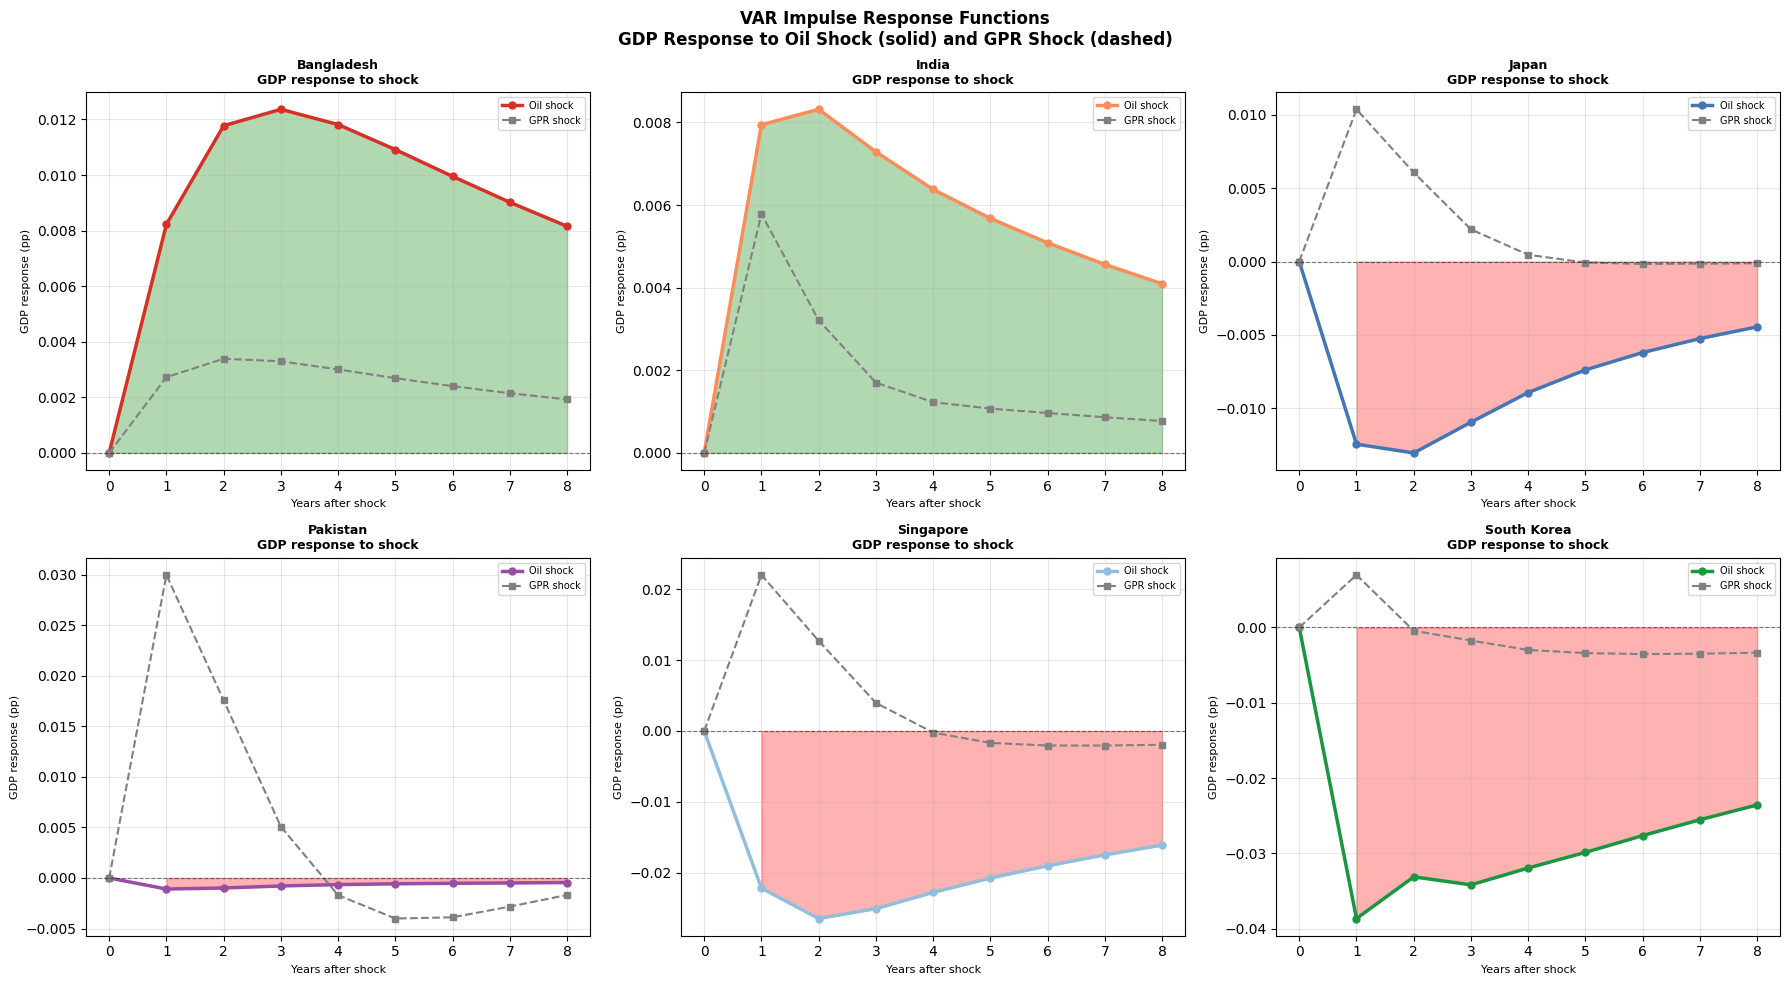

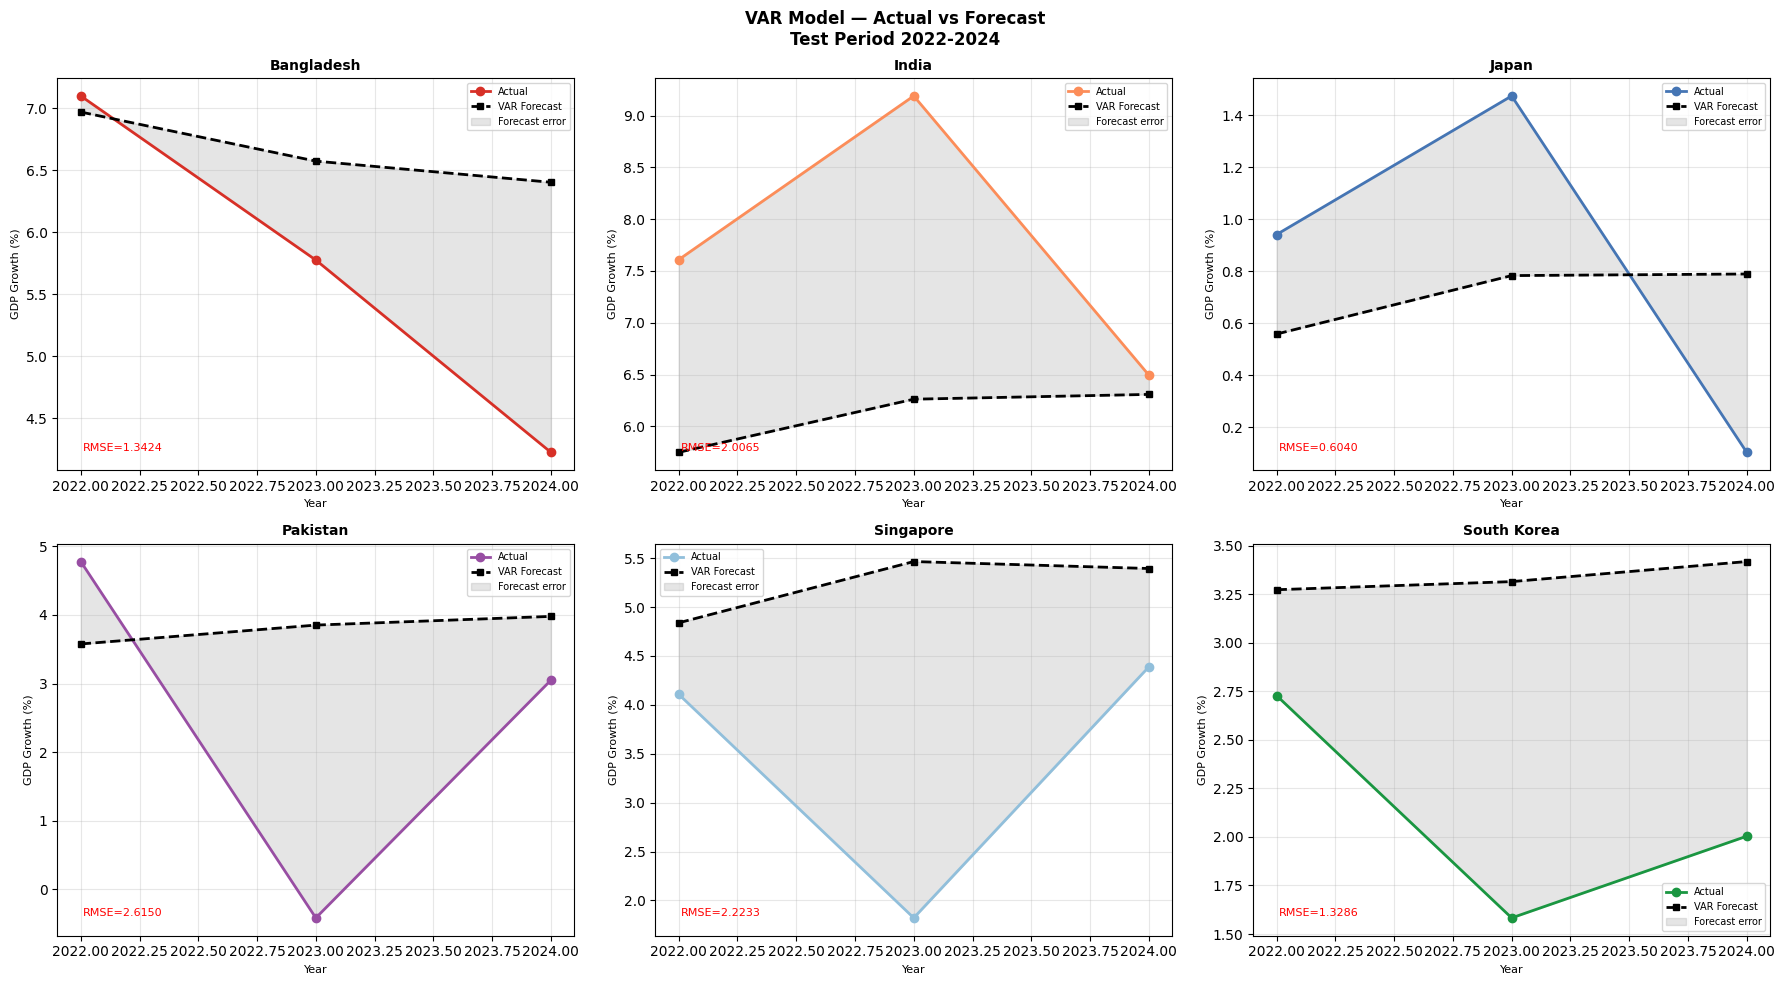


VAR RESULTS SUMMARY

Country         Lag   RMSE     MAE      MAPE%    AIC       
-------------------------------------------------------
Bangladesh          1   1.3424   1.0360    22.42%      13.44
India               1   2.0065   1.6590    19.74%      15.53
Japan               1   0.6040   0.5865   248.34%      12.62
Pakistan            1   2.6150   2.1327   361.34%      15.50
Singapore           1   2.2233   1.7940    80.27%      15.13
South Korea         1   1.3286   1.2303    66.65%      15.04

Saved:
  var_results.csv
  var_irf_data.csv
  figures/var_irf.png
  figures/var_actual_vs_forecast.png

Model 1 VAR complete!
Next → Model 2 Random Forest


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.var_model import VAR
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

panel = pd.read_csv(
    "dissertation_data/processed/panel_final.csv"
)

print("=" * 55)
print("MODEL 1 — VAR (Final Version)")
print("=" * 55)
print("Variables: gdp_growth, brent_crude_usd,")
print("           inflation, gpr_global")
print("Differencing: NONE — all variables stationary")
print("Lag selection: AIC (max=2)")
print("Train: 1990-2019 | Test: 2022-2024")

var_vars = [
    'gdp_growth',
    'brent_crude_usd',
    'inflation',
    'gpr_global',
]

countries = sorted(panel['country'].unique())

colors_country = {
    'Bangladesh':  '#d73027',
    'India':       '#fc8d59',
    'Japan':       '#4575b4',
    'Pakistan':    '#984ea3',
    'Singapore':   '#91bfdb',
    'South Korea': '#1a9641'
}

var_results   = {}
var_forecasts = {}
irf_data      = {}

# ── IRF plots ─────────────────────────────────────────
fig_irf, axes_irf = plt.subplots(
    2, 3, figsize=(18, 10)
)
axes_irf = axes_irf.flatten()

for idx, country in enumerate(countries):
    print(f"\n{'='*45}")
    print(f"VAR — {country}")
    print(f"{'='*45}")

    df_c = (panel[panel['country'] == country]
            .sort_values('year')
            .reset_index(drop=True))

    # No differencing — use raw values
    df_train = (df_c[df_c['year'] <= 2019]
                [var_vars].dropna().copy())
    df_test  = (df_c[df_c['year'] >= 2022]
                [var_vars].dropna().copy())

    print(f"Train rows: {len(df_train)}")
    print(f"Test rows:  {len(df_test)}")

    try:
        # ── Fit VAR ───────────────────────────────────
        model       = VAR(df_train)
        lag_result  = model.select_order(maxlags=2)
        optimal_lag = lag_result.aic
        optimal_lag = max(1, min(int(optimal_lag), 2))

        fitted = model.fit(optimal_lag)

        print(f"Optimal lag (AIC): {optimal_lag}")
        print(f"AIC:               {fitted.aic:.2f}")

        # ── IRF ───────────────────────────────────────
        irf      = fitted.irf(periods=8)
        irf_vals = irf.irfs

        gdp_idx   = var_vars.index('gdp_growth')
        brent_idx = var_vars.index('brent_crude_usd')
        gpr_idx   = var_vars.index('gpr_global')

        gdp_oil_response = irf_vals[
            :, gdp_idx, brent_idx
        ]
        gdp_gpr_response = irf_vals[
            :, gdp_idx, gpr_idx
        ]

        irf_data[country] = {
            'gdp_oil': gdp_oil_response.tolist(),
            'gdp_gpr': gdp_gpr_response.tolist(),
        }

        periods = range(len(gdp_oil_response))

        ax = axes_irf[idx]
        ax.plot(
            periods, gdp_oil_response,
            color=colors_country[country],
            linewidth=2.5, marker='o',
            markersize=5, label='Oil shock'
        )
        ax.plot(
            periods, gdp_gpr_response,
            color='gray', linewidth=1.5,
            linestyle='--', marker='s',
            markersize=4, label='GPR shock'
        )
        ax.fill_between(
            periods, gdp_oil_response, 0,
            where=[v < 0 for v in gdp_oil_response],
            alpha=0.3, color='red'
        )
        ax.fill_between(
            periods, gdp_oil_response, 0,
            where=[v >= 0 for v in gdp_oil_response],
            alpha=0.3, color='green'
        )
        ax.axhline(
            y=0, color='black',
            linestyle='--', alpha=0.5,
            linewidth=0.8
        )
        ax.set_title(
            f'{country}\nGDP response to shock',
            fontweight='bold', fontsize=9
        )
        ax.set_xlabel('Years after shock', fontsize=8)
        ax.set_ylabel('GDP response (pp)', fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

        # ── Forecast ──────────────────────────────────
        last_obs    = df_train.values[-optimal_lag:]
        n_steps     = len(df_test)
        forecast    = fitted.forecast(
            last_obs, steps=n_steps
        )
        forecast_df = pd.DataFrame(
            forecast, columns=var_vars
        )

        actual_gdp   = df_test['gdp_growth'].values
        forecast_gdp = forecast_df['gdp_growth'].values
        min_len      = min(
            len(actual_gdp), len(forecast_gdp)
        )
        actual_gdp   = actual_gdp[:min_len]
        forecast_gdp = forecast_gdp[:min_len]

        rmse = np.sqrt(mean_squared_error(
            actual_gdp, forecast_gdp
        ))
        mae  = np.mean(np.abs(
            actual_gdp - forecast_gdp
        ))
        mape = np.mean(np.abs(
            (actual_gdp - forecast_gdp) /
            (np.abs(actual_gdp) + 1e-10)
        )) * 100

        var_results[country] = {
            'lag':     optimal_lag,
            'aic':     round(fitted.aic, 2),
            'rmse':    round(rmse, 4),
            'mae':     round(mae, 4),
            'mape':    round(mape, 2),
            'n_train': len(df_train),
            'n_test':  len(df_test),
        }

        var_forecasts[country] = {
            'actual':   actual_gdp.tolist(),
            'forecast': forecast_gdp.tolist(),
        }

        print(f"RMSE: {rmse:.4f}")
        print(f"MAE:  {mae:.4f}")
        print(f"MAPE: {mape:.2f}%")

    except Exception as e:
        print(f"ERROR: {e}")
        var_results[country] = {
            'lag': None, 'aic': None,
            'rmse': None, 'mae': None,
            'mape': None
        }

# ── IRF plot ──────────────────────────────────────────
plt.suptitle(
    'VAR Impulse Response Functions\n'
    'GDP Response to Oil Shock (solid) '
    'and GPR Shock (dashed)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    'dissertation_data/processed/figures/var_irf.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

# ── Actual vs Forecast plot ───────────────────────────
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 10))
axes2 = axes2.flatten()

for idx, country in enumerate(countries):
    ax = axes2[idx]
    if var_forecasts.get(country):
        actual   = var_forecasts[country]['actual']
        forecast = var_forecasts[country]['forecast']
        years    = list(range(2022, 2022 + len(actual)))

        ax.plot(
            years, actual,
            color=colors_country[country],
            linewidth=2, marker='o',
            markersize=6, label='Actual'
        )
        ax.plot(
            years, forecast,
            color='black', linewidth=2,
            linestyle='--', marker='s',
            markersize=5, label='VAR Forecast'
        )
        ax.fill_between(
            years, actual, forecast,
            alpha=0.2, color='gray',
            label='Forecast error'
        )
        ax.set_title(
            f'{country}',
            fontweight='bold', fontsize=10
        )
        ax.set_xlabel('Year', fontsize=8)
        ax.set_ylabel('GDP Growth (%)', fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

        if var_results[country]['rmse']:
            ax.text(
                0.05, 0.05,
                f"RMSE={var_results[country]['rmse']:.4f}",
                transform=ax.transAxes,
                fontsize=8, color='red'
            )

plt.suptitle(
    'VAR Model — Actual vs Forecast\n'
    'Test Period 2022-2024',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    'dissertation_data/processed/figures/'
    'var_actual_vs_forecast.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

# ── Results summary ───────────────────────────────────
print("\n" + "=" * 55)
print("VAR RESULTS SUMMARY")
print("=" * 55)
print(f"\n{'Country':15s} {'Lag':5s} {'RMSE':8s} "
      f"{'MAE':8s} {'MAPE%':8s} {'AIC':10s}")
print("-" * 55)

for country, res in var_results.items():
    if res['rmse'] is not None:
        print(
            f"{country:15s} {res['lag']:5d} "
            f"{res['rmse']:8.4f} {res['mae']:8.4f} "
            f"{res['mape']:8.2f}% {res['aic']:10.2f}"
        )
    else:
        print(f"{country:15s} ERROR")

# Save
pd.DataFrame(var_results).T.to_csv(
    'dissertation_data/processed/var_results.csv'
)
pd.DataFrame(irf_data).to_csv(
    'dissertation_data/processed/var_irf_data.csv'
)

print("\nSaved:")
print("  var_results.csv")
print("  var_irf_data.csv")
print("  figures/var_irf.png")
print("  figures/var_actual_vs_forecast.png")
print("\nModel 1 VAR complete!")
print("Next → Model 2 Random Forest")